#  K-Means clustering and visualise results using PCA.

## loading

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Load the dataset
df = pd.read_csv('..\\data\\q2_customers.csv')
# Display the first 5 rows of the dataset
df.head()


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,30,43075,9,2080,45,6
1,19,14496,11,454,8,3
2,43,57632,6,2144,16,4
3,30,15629,10,801,0,2
4,19,14901,16,396,17,1


In [2]:
# Summary statistics
df.describe()

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
count,500.00000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,40.45200,48856.948000,8.414000,2682.286000,49.466000,4.658000
std,14.42664,32856.795353,5.324595,2274.957339,49.699143,2.438222
min,18.00000,5038.000000,1.000000,212.000000,0.000000,1.000000
25%,28.00000,19213.250000,4.000000,727.750000,12.000000,3.000000
50%,41.00000,44257.000000,8.000000,2051.500000,33.000000,4.000000
75%,50.00000,75373.000000,12.000000,4223.750000,61.250000,6.000000
max,69.00000,119757.000000,19.000000,7981.000000,179.000000,9.000000


In [3]:
# Check for missing values
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   age                       500 non-null    int64
 1   annual_spend              500 non-null    int64
 2   visits_per_month          500 non-null    int64
 3   basket_size               500 non-null    int64
 4   days_since_last_visit     500 non-null    int64
 5   num_categories_purchased  500 non-null    int64
dtypes: int64(6)
memory usage: 23.6 KB


In [4]:
df.columns

Index(['age', 'annual_spend', 'visits_per_month', 'basket_size',
       'days_since_last_visit', 'num_categories_purchased'],
      dtype='str')

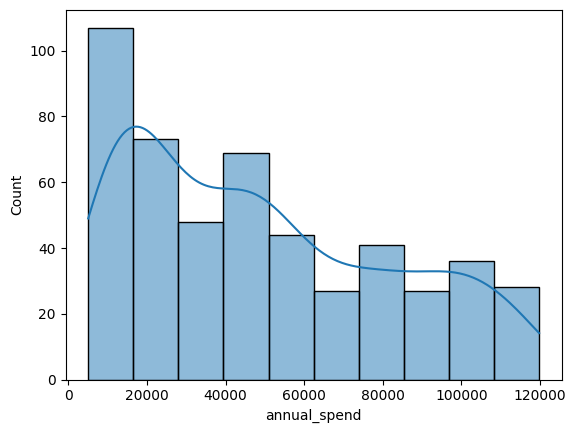

In [5]:
# Visualize the distribution of a specific column 
sns.histplot(df['annual_spend'], kde=True)
plt.show()


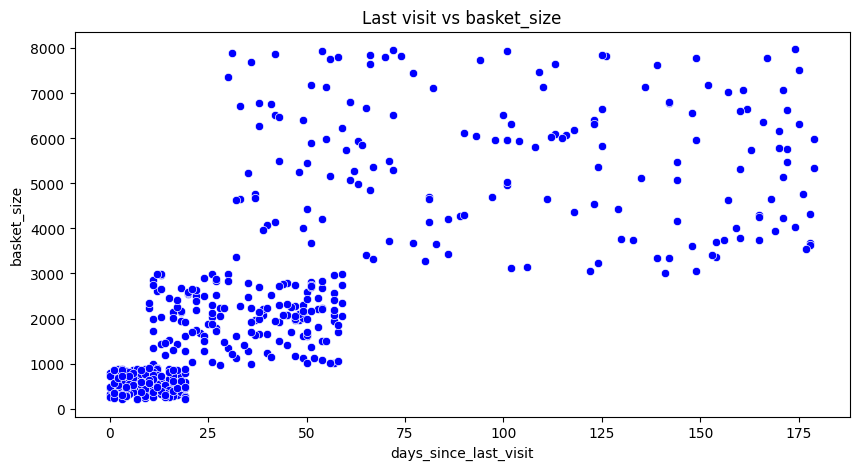

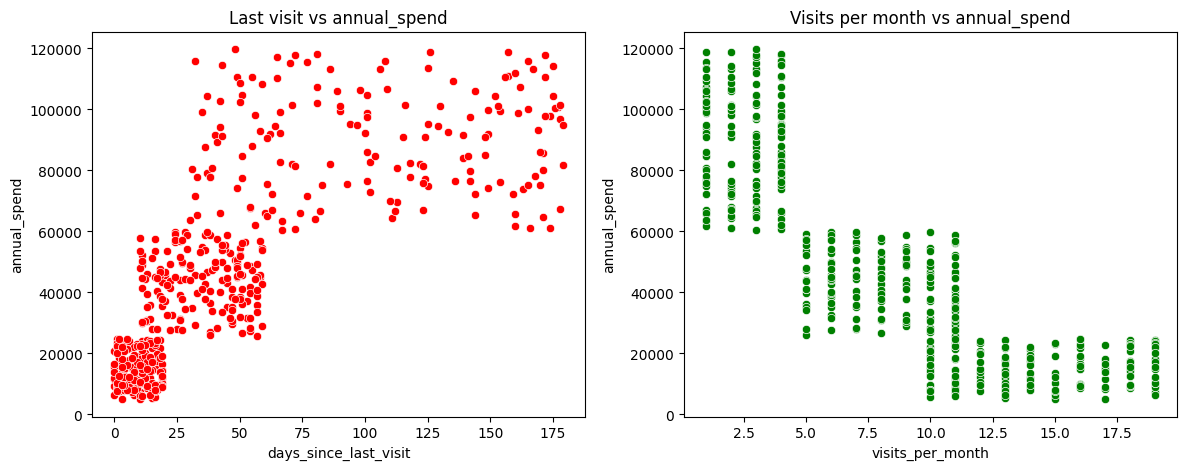

In [6]:
# Visualization using scatter plot
plt.figure(figsize=(10, 5))
sns.scatterplot(x='days_since_last_visit', y='basket_size', data=df, color='blue')
plt.ylabel('basket_size')
plt.title('Last visit vs basket_size')
plt.show()


plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
sns.scatterplot(x='days_since_last_visit', y='annual_spend', data=df, color='red')
plt.ylabel('annual_spend')
plt.title('Last visit vs annual_spend')
plt.subplot(1, 2, 2)
sns.scatterplot(x='visits_per_month', y='annual_spend', data=df, color='green')
plt.ylabel('annual_spend')
plt.title('Visits per month vs annual_spend')
plt.show()



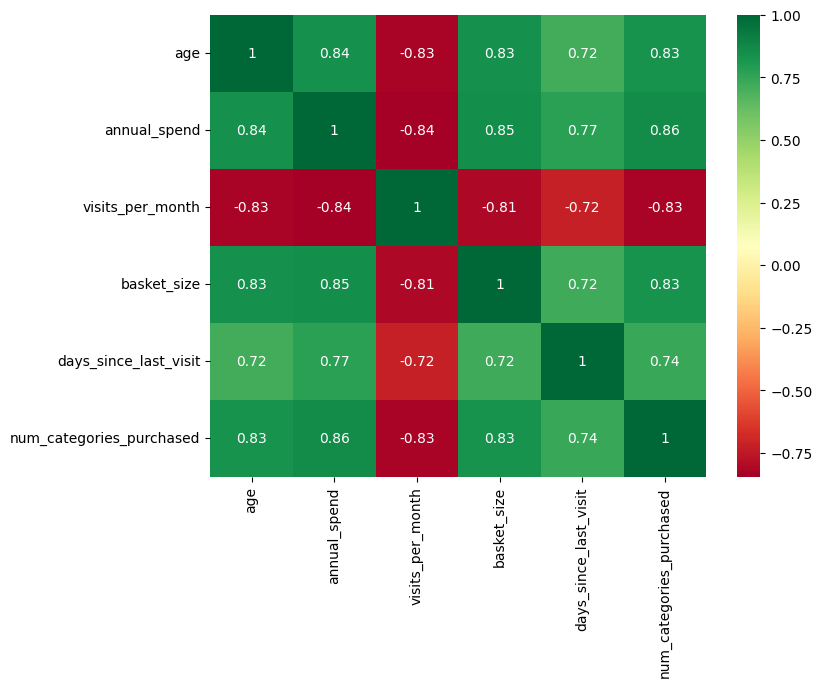

In [7]:
# Correlation heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='RdYlGn')
plt.show()

## 1. Data Preparation

In [8]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
# scaler.fit_transform(data)
scaled_data = scaler.fit_transform(df)
scaled_df = pd.DataFrame(scaled_data, columns=df.columns)
scaled_df.head()

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,-0.725219,-0.176150,0.110166,-0.265011,-0.089951,0.550952
1,-1.488460,-1.046826,0.486157,-0.980466,-0.835176,-0.680685
2,0.176795,0.267337,-0.453822,-0.236851,-0.674046,-0.270139
3,-0.725219,-1.012309,0.298161,-0.827783,-0.996306,-1.091230
4,-1.488460,-1.034488,1.426136,-1.005986,-0.653905,-1.501776


### Why scaling is essential before K-Means:

#### K-Means clustering is based on distance (Euclidean distance). If features are on different scales (e.g., age vs annual_spend), larger-scale features dominate the clustering process.

`Example:`

- annual_spend (thousands) >> visits_per_month (single digits)

- Without scaling → model becomes biased toward high-value features.

Scaling ensures:

- All features contribute equally
- Better cluster formation
- Faster convergence

## 2. Choosing K — Elbow Method

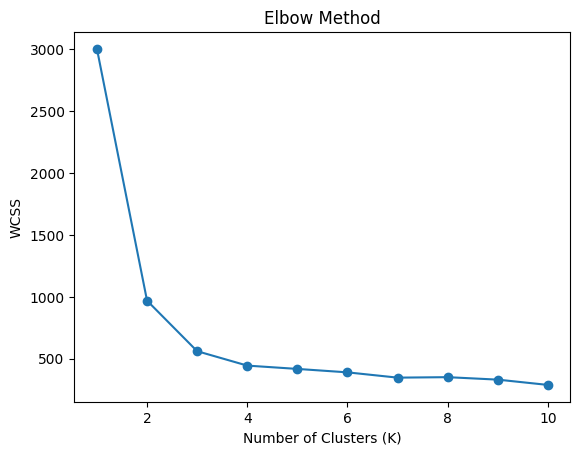

In [9]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_df)
    wcss.append(kmeans.inertia_)

# Plot
plt.figure()
plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()

### The elbow point is where the decrease in WCSS slows down significantly.

Sharp drop till **K = 3**
After that → gradual decrease

Example justification:

- The elbow occurs at K = 3, where the WCSS reduction slows, indicating adding more clusters gives diminishing returns.

## 3. K-Means Clustering

In [10]:
k = 3

kmeans = KMeans(n_clusters=k, random_state=42, n_init=10 )
clusters = kmeans.fit_predict(scaled_df)

# Add cluster column
df['cluster'] = clusters

# Centroids
centroids = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=df.columns[:-1]
)

centroids

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,24.676471,14847.370588,14.341176,558.970588,9.076471,2.111765
1,56.769697,89413.333333,2.527273,5530.545455,105.357576,7.515152
2,40.387879,43340.733333,8.193939,2021.684848,35.187879,4.424242


Cluster 0:

Young customers
Low spending
Frequent visits
👉 "Budget frequent shoppers"

Cluster 1:

High spend
Large basket size
👉 "Premium high-value customers"

Cluster 2:

Infrequent visits
High days since last visit
👉 "At-risk / churn customers"

## 4. Dimensionality Reduction with PCA

In [11]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_df)

# Explained variance
print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)

# Loadings
loadings = pd.DataFrame(
    pca.components_,
    columns=scaled_df.columns,
    index=['PC1', 'PC2']
)

loadings

Explained Variance Ratio:
[0.83560354 0.05568764]


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
PC1,0.411569,0.42154,-0.410399,0.412012,0.378582,0.414017
PC2,-0.259432,-0.03327,0.208318,-0.195402,0.911194,-0.140479


Explained Variance:

- PC1 explains ~ 83.56% of total variance
- PC2 explains ~ 5.57% of total variance

Interpretation of Components:

**PC1: Customer Value & Purchase Behavior**

High loadings on:
annual_spend
basket_size
num_categories_purchased
age
Negative loading on:
visits_per_month

**`👉 Represents high-value customers with larger purchases but lower visit frequency`**

PC2: Customer Recency

Strong loading on:
days_since_last_visit

**`👉 Represents how recently a customer interacted (engagement timing)`**

## 5. Cluster Visualisation 

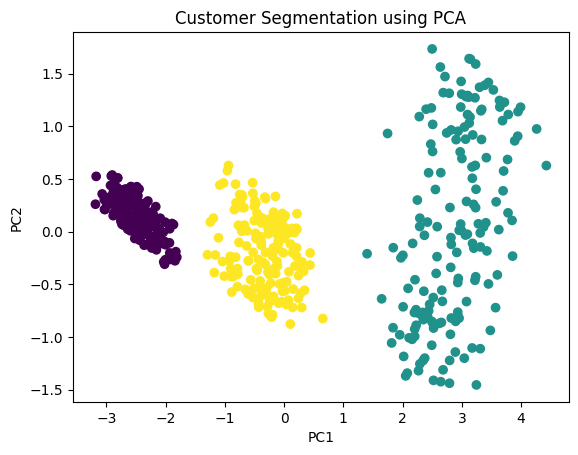

In [ ]:
plt.figure()

plt.scatter(
    pca_data[:, 0],
    pca_data[:, 1],
    c=df['cluster']
)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Customer Segmentation using PCA')
plt.show()